In [148]:
# import packages
%matplotlib inline

import os
import sys
from multiprocessing import Process, Queue
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from dataclasses import dataclass
sys.path.append('~/src/GSASII/GSASII/')

In [149]:
# ====== テストデータへのリンク ======
import os
from pathlib import Path

TUTDIR = "~/src/GSASII/GSAS-II-tutorials/TOF-CW Joint Refinement/data"
WORKDIR = "work_tof/tutorial_GSASII/NAC_BBO"


Path(WORKDIR).mkdir(parents=True, exist_ok=True)
Path("%s/cycle"%(WORKDIR)).mkdir(parents=True, exist_ok=True)

# CIF
src = Path("%s/NAC.cif"%(TUTDIR)).expanduser()
dst = Path("%s/NAC.cif"%(WORKDIR)).expanduser()
dst.unlink(missing_ok=True)
dst.symlink_to(src)


# TOF powder data
src = Path("%s/PG3_22048.gsa"%(TUTDIR)).expanduser()
dst = Path("%s/PG3_22048.gsa"%(WORKDIR)).expanduser()
dst.unlink(missing_ok=True)
dst.symlink_to(src)


# TOF instrument parameter
src = Path("%s/POWGEN_1066.instprm"%(TUTDIR)).expanduser()
dst = Path("%s/POWGEN_1066.instprm"%(WORKDIR)).expanduser()
dst.unlink(missing_ok=True)
dst.symlink_to(src)

In [150]:
# Configurations

### Change here ###
STUDY_NAME = 'NAC'
RANDOM_SEED = 1024

DATA_DIR = WORKDIR
# all output files include GSAS project file (*.gpx) will be saved in WORK_DIR
WORK_DIR = WORKDIR + '/cycle'

In [151]:
# make directories
! rm -f $WORK_DIR/$STUDY_NAME*
! mkdir -p $WORK_DIR

zsh:1: no matches found: work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC*


In [152]:
@dataclass
class ProjectConfig:
    work_dir: str
    random_seed: int
    data_dir: str
    cif_file: str
    gsa_file: str
    prm_file: str

In [153]:
class Project:
    def __init__(self, config, trial_number):
        import GSASIIscriptable as G2sc

        self.gpx = G2sc.G2Project(
            newgpx=os.path.join(
                config.work_dir,
                f'{STUDY_NAME}_seed{config.random_seed}_trial_{trial_number}.gpx'
            )
        )

        self.hist1 = self.gpx.add_powder_histogram(
            os.path.join(config.data_dir, config.gsa_file),
            os.path.join(config.data_dir, config.prm_file)
        )

        self.phase0 = self.gpx.add_phase(
            os.path.join(config.data_dir, config.cif_file),
            phasename=config.cif_file.split(".cif")[0],
            histograms=[self.hist1]
        )

        self.inst1 = self.hist1.data["Instrument Parameters"][0]
        
        # isotropic U
        for atom in self.phase0.data['Atoms']:
            atom[9] = 'I'

    def refine_and_calc_Rwp(self, param_dict):
        self.gpx.do_refinements([param_dict])
        for hist in self.gpx.histograms():
            _, Rwp = hist.name, hist.get_wR()
        return Rwp

    def fix_inst_params(self, keys=None):
        if keys is None:
            keys = [
                'Zero', 'difC',
                'alpha', 'beta-0', 'beta-1', 'beta-q'
            ]
        for key in keys:
            if key in inst1 and len(inst1[key]) >= 3:
                inst1[key][2] = False

    def fix_cells(self):
        self.phase0.set_refinements({"Cell": False})

    def fix_background(self):
        self.hist1.set_refinements({"Background": False})

    def fix_scale(self):
        self.hist1.data["Sample Parameters"]["Scale"][1] = False

    def fix_params(self, flag):
        if flag is None:
            return

        if flag == 'Instrument Parameters':
            self.fix_inst_params()
        elif flag == 'Cell':
            self.fix_cells()
        elif flag == 'Background':
            self.fix_background()
        elif flag == 'Scale':
            self.fix_scale()
        else:
            raise ValueError(f"Unknown flag: {flag}")

In [154]:
# Example usage:
config = ProjectConfig(
    work_dir=WORK_DIR,
    random_seed=RANDOM_SEED,
    data_dir=DATA_DIR,
    cif_file='NAC.cif',
    #csv_file='NAC.csv',
    gsa_file='PG3_22048.gsa',
    prm_file='POWGEN_1066.instprm'
)

In [155]:
def objective(trial, config):

    # -------------------------
    #      Search space
    # -------------------------

    # Limits
    limits_lb = trial.suggest_float('Limits lower bound', 11500.0, 12500.0)
    limits_ub = trial.suggest_float('Limits upper bound', 95000.0,105000.0)
    limits_refine = trial.suggest_categorical('limits refine',[True, False])
    refdict_limits = {'set': {'Limits': [limits_lb, limits_ub]},'refine': limits_refine}

    # Background
    background_type = trial.suggest_categorical(
        'Background type', ['chebyschev-1',
                            #'cosine',
                            #'Q^2 power series',
                            #'Q^-2 power series',
                            #'lin interpolate',
                            #'inv interpolate',
                            #'log interpolate'
                           ])
    no_coeffs = trial.suggest_int('Number of coefficients', 1, 7)  # [1, 7]
    background_refine = trial.suggest_categorical('Background refine',[True, False])
    refdict_background = {
        'set': {'Background': {'type': background_type,
                                'no. coeffs': no_coeffs,
                                'refine': background_refine}}
    }

    # Instrument parameters
    instrument_parameters_refine = []

    for p in ['Zero', 'difC']:
        if trial.suggest_categorical(
            f'Instrument_parameters refine {p}',
            [True, False]
        ):
            instrument_parameters_refine.append(p)

    for p in ['alpha', 'beta-0', 'beta-1', 'beta-q']:
        if trial.suggest_categorical(
            f'Peakshape_parameters refine {p}',
            [True, False]
        ):
            instrument_parameters_refine.append(p)

    cell_refine = trial.suggest_categorical(
        'cell refine',
        [True, False]
    )

    refdict_cell_and_inst = {
        'set': {'Cell': cell_refine,
                'Instrument Parameters': instrument_parameters_refine}
    }

    # Fix instrument parameters after one refinement
    refdict_fix_inst = {
        'clear': {'Instrument Parameters': ['Zero', 'difC','alpha', 'beta-0', 'beta-1', 'beta-q']}
    }

    # Scale
    sample_parameters_refine = []
    for p in ['Scale']:
        if trial.suggest_categorical(
            f'Sample_parameters refine {p}',
            [True, False]
        ):
            sample_parameters_refine.append(p)

    refdict_scale = {
        'set': {'Sample Parameters': sample_parameters_refine}
    }

    # Atomic positions
    refdict_atoms_xyz = {
        'set': {'Atoms': {'all': 'X'}}
    }

    # Atomic displacement parameters
    refdict_atoms_u = {
        'set': {'Atoms': {'all': 'U'}}
    }

    # Atomic displacement parameters
    refdict_atoms_all = {
        'set': {'Atoms': {'all': 'XU'}}
    }

    # Final refinement
    # Instrument Parameters はここに入れない
    refdict_final = {
        'set': {
            'Limits': [12000.0, 100000.0],
            'Background': {
                'type': 'chebyschev-1',
                'no. coeffs': no_coeffs,
                'refine': True
            },
            'Cell': True,
            'Sample Parameters': ['Scale'],
            'Atoms': {
                'all': 'XU'
            }
        },
        'refine': True
    }


    #fixdict_cell = {
    #    gpx.phases()[0].set_refinements({"Cell": False})
    #}



        
    refine_params_list = [
        refdict_scale,
        refdict_limits,
        refdict_background,
        refdict_cell_and_inst,
        #refdict_fix_inst,
        refdict_atoms_xyz,
        refdict_atoms_u,
        #refdict_atoms_all,
        #refdict_final,
    ]

    def evaluate(config, trial_number, refine_params_list):
        ERROR_PENALTY = 1e9      
        try:
            print(config)
            print(trial_number)
            print(refine_params_list)
            # todo: ここを実装（trial_number）を渡す
            project = Project(config, trial_number)
            for params in refine_params_list:
                Rwp = project.refine_and_calc_Rwp(params)                    
            # validate Uiso >= 0
            phase_Y2O3 = project.gpx.phases()[0]
            u_iso_list = [atom.uiso for atom in phase_Y2O3.atoms()]
            if min(u_iso_list) < 0:
                # Uiso < 0
                Rwp = ERROR_PENALTY
            return Rwp
            
        except Exception as e:
            print(e, file=sys.stderr)
            return ERROR_PENALTY

    Rwp = evaluate(config, trial.number, refine_params_list)
    
    return Rwp

In [156]:
# Create Optuna study
study = optuna.create_study(study_name=STUDY_NAME + '_seed%s' % (RANDOM_SEED),
                            storage=f"sqlite:///{config.work_dir}/history_sqlite.db", 
                            load_if_exists=True,
                            sampler=optuna.samplers.TPESampler(n_startup_trials=20, seed=RANDOM_SEED))

[I 2026-06-17 14:06:13,378] A new study created in RDB with name: NAC_seed1024


Run 200 refinements to find the best configuration. It may take abount an hour to complete.

In [157]:
# Optimize
#study.optimize(objective, n_trials=200, n_jobs=1)
#study.optimize(func=lambda trial: objective(trial, config), n_trials=100)
study.optimize(func=lambda trial: objective(trial, config), n_trials=25)

ProjectConfig(work_dir='work_tof/tutorial_GSASII/NAC_BBO/cycle', random_seed=1024, data_dir='work_tof/tutorial_GSASII/NAC_BBO', cif_file='NAC.cif', gsa_file='PG3_22048.gsa', prm_file='POWGEN_1066.instprm')
0
[{'set': {'Sample Parameters': []}}, {'set': {'Limits': [12147.691230661978, 104969.13579872574]}, 'refine': False}, {'set': {'Background': {'type': 'chebyschev-1', 'no. coeffs': 5, 'refine': True}}}, {'set': {'Cell': False, 'Instrument Parameters': ['difC', 'alpha']}}, {'set': {'Atoms': {'all': 'X'}}}, {'set': {'Atoms': {'all': 'U'}}}]
/Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/PG3_22048.gsa read by Reader GSAS powder data
Instrument parameters read: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/POWGEN_1066.instprm (G2 fmt) bank 2
Keyed packet: ['Ca1', '0.0083', '0.0096', '0.0080', '0.0000', '0.0000', '-0.0000']
Keyed packet: ['Al1', '0.0078', '0.0078', '0.0078', '-0.0007', '-0.0007', '-0.0007']
Keyed packet: ['Na1', '0.0255', '

/opt/miniconda3/envs/powder/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1529: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/opt/miniconda3/envs/powder/lib/python3.13/site-packages/GSASII/GSASIImath.py:369: UserWarning: Warning: converting a masked element to nan.
  'Cycle %d: %.2fs, Chi**2: %.5g for %d obs., Lambda: %.3g,  Delta: %.3g, SVD=%d'%
/opt/miniconda3/envs/powder/lib/python3.13/site-packages/numpy/ma/core.py:4450: RuntimeWarning: invalid value encountered in multiply
  self._data.__imul__(other_data)


Cycle 2: 0.80s, Chi**2: nan for 5365 obs., Lambda: 0,  Delta: nan, SVD=0


/opt/miniconda3/envs/powder/lib/python3.13/site-packages/GSASII/GSASIIstrMain.py:372: UserWarning: Warning: converting a masked element to nan.
  printFile.write(' wR = %7.2f%%, chi**2 = %12.6g, GOF = %6.2f\n'%(Rvals['Rwp'],Rvals['chisq'],Rvals['GOF']))
/opt/miniconda3/envs/powder/lib/python3.13/site-packages/GSASII/GSASIIstrMain.py:404: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  print('Maximum shift/esd = {:.3f} for all cycles'.format(Rvals['Max shft/sig']))
/opt/miniconda3/envs/powder/lib/python3.13/site-packages/GSASII/GSASIImpsubs.py:230: RuntimeWarning: invalid value encountered in divide
  yp[iBeg:iFin] = refl[11+im]*refl[9+im]*fp*cw[iBeg:iFin]/sumfp


Maximum shift/esd = -- for all cycles
Note highly correlated parameters:
 ** :0:alpha and :0:difC (@99.91%)


...

divergence: chi^2 4.6696e+06 on 5181 obs. (0 SVD zeros)
	increasing Marquardt lambda to 1.0e-03
divergence: chi^2 4.6706e+06 on 5181 obs. (0 SVD zeros)
	increasing Marquardt lambda to 1.0e-02
divergence: chi^2 4.6809e+06 on 5181 obs. (0 SVD zeros)
	increasing Marquardt lambda to 1.0e-01
Cycle 1: 0.89s, Chi**2: 3.7463e+05 for 5181 obs., Lambda: 0.1,  Delta: 0.354, SVD=0
Cycle 2: 0.70s, Chi**2: 2.5282e+05 for 5181 obs., Lambda: 0.1,  Delta: 0.325, SVD=0
Maximum shift/esd = 16.499 for all cycles
Note highly correlated parameters:
 ** :0:Back;0 and :0:Back;1 (@96.27%)
Read from file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_24.bak0.gpx
Save to file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_24.gpx
GPX file save successful
 Refinement results are in file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_24.lst
 ***** Refinement successfu

/opt/miniconda3/envs/powder/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1529: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/opt/miniconda3/envs/powder/lib/python3.13/site-packages/GSASII/GSASIImath.py:369: UserWarning: Warning: converting a masked element to nan.
  'Cycle %d: %.2fs, Chi**2: %.5g for %d obs., Lambda: %.3g,  Delta: %.3g, SVD=%d'%
/opt/miniconda3/envs/powder/lib/python3.13/site-packages/numpy/ma/core.py:4450: RuntimeWarning: invalid value encountered in multiply
  self._data.__imul__(other_data)
/opt/miniconda3/envs/powder/lib/python3.13/site-packages/GSASII/GSASIIstrMain.py:372: UserWarning: Warning: converting a masked element to nan.
  printFile.write(' wR = %7.2f%%, chi**2 = %12.6g, GOF = %6.2f\n'%(Rvals['Rwp'],Rvals['chisq'],Rvals['GOF']))
/opt/miniconda3/envs/powder/lib/python3.13/site-packages/GSASII/GSASIIstrMain.py:404: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may e

Cycle 2: 0.36s, Chi**2: nan for 5181 obs., Lambda: 0.001,  Delta: nan, SVD=0
Maximum shift/esd = -- for all cycles
Note highly correlated parameters:
 ** :0:beta-0 and :0:beta-1 (@99.31%)
 ** :0:beta-0 and :0:beta-q (@99.14%)
 ** :0:beta-1 and :0:beta-q (@99.63%)
Read from file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_24.bak0.gpx
Save to file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_24.gpx
GPX file save successful
 Refinement results are in file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_24.lst
 ***** Refinement successful *****
Reported from refinement:
Note highly correlated parameters:
 ** :0:beta-0 and :0:beta-1 (@99.31%)
 ** :0:beta-0 and :0:beta-q (@99.14%)
 ** :0:beta-1 and :0:beta-q (@99.63%)
gpx file saved as /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_24.gpx
 He

/opt/miniconda3/envs/powder/lib/python3.13/site-packages/numpy/ma/core.py:4450: RuntimeWarning: invalid value encountered in multiply
  self._data.__imul__(other_data)
/opt/miniconda3/envs/powder/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1529: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/opt/miniconda3/envs/powder/lib/python3.13/site-packages/GSASII/GSASIImath.py:243: UserWarning: Warning: converting a masked element to nan.
  G2fil.G2Print('initial chi^2 %.5g with %d obs.'%(chisq00,Nobs))
/opt/miniconda3/envs/powder/lib/python3.13/site-packages/GSASII/GSASIIstrMath.py:4631: RuntimeWarning: invalid value encountered in add
  dMdv[varylist.index(name)][iBeg:iFin] += dFdvDict[name][iref]*corr
/opt/miniconda3/envs/powder/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/miniconda3/envs/powder/lib/python3.

ouch #2 bad SVD inversion; dropping terms for for variable(s) #[np.int64(0)]
ouch #2 bad SVD inversion; dropping terms for for variable(s) #[np.int64(0)]
ouch #2 bad SVD inversion; dropping terms for for variable(s) #[np.int64(0)]
giving up with ouch #2
****ERROR - Refinement failed
Note refinement problem:
SVD inversion failure

 ***** Refinement error *****
Note refinement problem:
SVD inversion failure


**** ERROR: Refinement failed ****


In [158]:
df = study.trials_dataframe()
df.rename(columns={'value': 'Rwp', 'number': 'trial'}, inplace=True)
df.columns = [
    c.replace('params_', '') if c.startswith('params_') else c
    for c in df.columns
]

df.drop(
    columns=['state', 'datetime_start', 'datetime_complete', 'duration'],
    inplace=True,
    errors='ignore'
)

df = df.sort_values('Rwp')

In [190]:
for i in range(20):
    print(df.iloc[i])
    print("---------")

trial                                            19
Rwp                                        9.240416
Background refine                              True
Background type                        chebyschev-1
Instrument_parameters refine Zero             False
Instrument_parameters refine difC              True
Limits lower bound                     11637.280781
Limits upper bound                    101632.265273
Number of coefficients                            4
Peakshape_parameters refine alpha              True
Peakshape_parameters refine beta-0             True
Peakshape_parameters refine beta-1            False
Peakshape_parameters refine beta-q            False
Sample_parameters refine Scale                 True
cell refine                                    True
limits refine                                  True
Name: 19, dtype: object
---------
trial                                           17
Rwp                                       9.336263
Background refine               

In [159]:
# Best configuration
study.best_params

{'Limits lower bound': 11637.280780556008,
 'Limits upper bound': 101632.26527275908,
 'limits refine': True,
 'Background type': 'chebyschev-1',
 'Number of coefficients': 4,
 'Background refine': True,
 'Instrument_parameters refine Zero': False,
 'Instrument_parameters refine difC': True,
 'Peakshape_parameters refine alpha': True,
 'Peakshape_parameters refine beta-0': True,
 'Peakshape_parameters refine beta-1': False,
 'Peakshape_parameters refine beta-q': False,
 'cell refine': True,
 'Sample_parameters refine Scale': True}

In [160]:
# Best Rwp
study.best_value

9.240416036518436

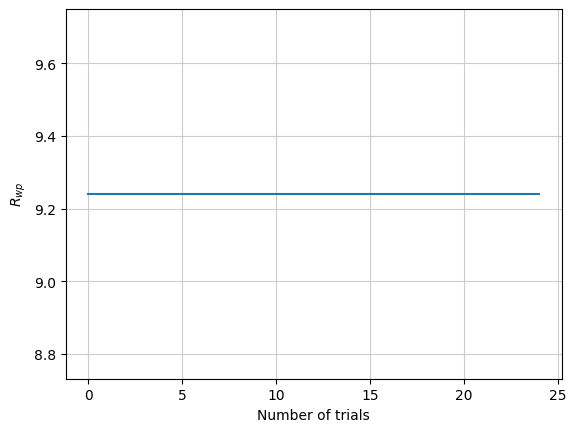

In [180]:
# Rwp plot
def rwp_plot():
    minvalues = [df.iloc[0]['Rwp']]
    for i in range(1, df.shape[0]):
        value = min(minvalues[-1], df.iloc[i]['Rwp'])
        #value = df.iloc[i]['Rwp']
        #print(value)
        minvalues.append(value)
    minvalues = pd.DataFrame(minvalues)
    
    minvalues.plot(legend=None)
#     plt.ylim([6, 16])
    plt.grid(color='#cccccc')
    plt.ylabel('$R_{wp}$')
    plt.xlabel('Number of trials')
    #plt.ylim(9.2, 9.3)
    plt.show()
    
rwp_plot()

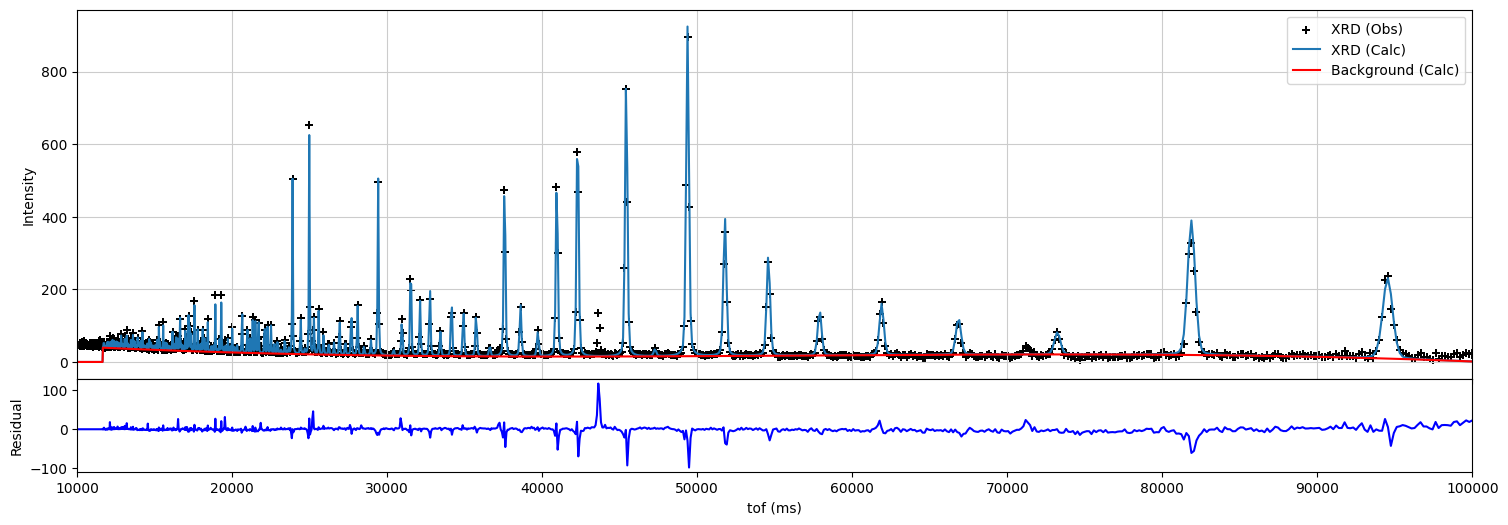

In [162]:
# Rietveld plot
def rietveld_plot():
    import GSASIIscriptable as G2sc

    gpx = G2sc.G2Project(
        '%s/%s_seed%s_trial_%s.gpx' % (WORK_DIR, STUDY_NAME, RANDOM_SEED, study.best_trial.number))

    hist1 = gpx.histograms()[0]
    phase0 = gpx.phases()[0]

    hist = hist1
    i = 5
    two_theta = hist.getdata("X")[::i]
    Yobs = hist.getdata("Yobs")[::i]
    Ycalc = hist.getdata("Ycalc")[::i]
    bg = hist.getdata("Background")[::i]
    residual = hist.getdata("Residual")[::i]

    fig = plt.figure(figsize=(18, 6))
    gs = GridSpec(5, 1, figure=fig)
    ax1 = fig.add_subplot(gs[:4, :])
    ax2 = fig.add_subplot(gs[4, :])
    fig.subplots_adjust(hspace=0)
    ax1.grid(color='#cccccc')

    ax1.scatter(two_theta, Yobs, marker='P', lw=0.0001, c='Black', label='XRD (Obs)')
    ax1.plot(two_theta, Ycalc, label='XRD (Calc)')
    ax1.plot(two_theta, bg, color='red', label='Background (Calc)')
    ax1.set_ylabel('Intensity')
    ax1.legend()
    ax2.plot(two_theta, residual, color='blue')
    plt.setp(ax1.get_xticklabels(), visible=False);
    # ax2.set_ylim(-6600, 6600)
    plt.xlabel(r'tof (ms)')
    ax2.set_ylabel('Residual')
    # change 2theta range according to your data
    ax1.set_xlim(10000, 100000)
    ax2.set_xlim(10000, 100000)
    plt.show()
    
rietveld_plot()